In [80]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
def api_url(url):
  headers = {'Accept': 'Application/json','X-CMC_PRO_API_KEY':'5886eb9a20404b62a095f4969c050c7e'}
  parameters = {'start':1,'limit':10,'convert':'INR'}
  response = requests.get(url,headers=headers,params=parameters)
  data = response.json()
  coins = []
  for item in data['data']:
      name = item['name']
      symbol = item['symbol']
      price = item['quote']['INR']['price']
      market_cap = item['quote']['INR']['market_cap']
      percent_change_24h = item['quote']['INR']['percent_change_24h']

      coins.append({
          'Name': name,
          'Symbol': symbol,
          'Price (INR)': price,
          'Market Cap': market_cap,
          '24h Change (%)': percent_change_24h
          })

  df = pd.DataFrame(coins)
  df['Price (INR)'] = round(df['Price (INR)'], 2)
  df.style.format({'24h Change (%)': '{:.2f}%'})

  plt.figure(figsize=(12, 6))
  sns.set_theme(style="darkgrid")

  # Create a scatter plot where bubble size represents Market Cap
  scatter = sns.scatterplot(
      data=df,
      x='Symbol',
      y='24h Change (%)',
      size='Market Cap',
      hue='24h Change (%)',
      palette='RdYlGn',
      sizes=(100, 1000),
      legend='brief'
  )
  plt.title('Top 15 Cryptocurrencies: 24h Performance & Market Cap Size', fontsize=14, fontweight='bold', pad=15)
  plt.xlabel('Cryptocurrency Token', fontsize=12)
  plt.ylabel('24h Price Change (%)', fontsize=12)
  plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7) # Baseline 0% change

  # Position the legend outside the plot area
  plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Market Cap (Billions)')
  plt.tight_layout()

  # Display the chart
  plt.show()

  return df

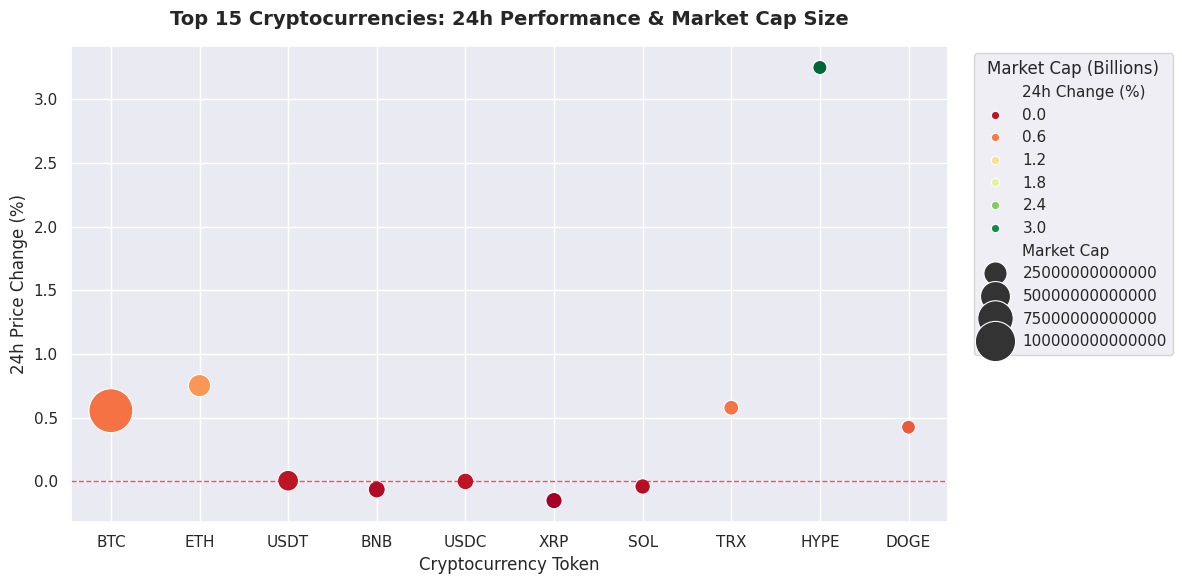

,Name,Symbol,Price (INR),Market Cap,24h Change (%)
0,Bitcoin,BTC,6056251.52,1.215574e+14,0.555446
1,Ethereum,ETH,180954.28,2.183791e+13,0.752089
2,Tether USDt,USDT,95.50,1.749039e+13,0.005928
3,BNB,BNB,57806.66,7.697751e+12,-0.062799
4,USDC,USDC,95.59,6.863703e+12,0.000372
5,XRP,XRP,95.54,5.988363e+12,-0.149966
6,Solana,SOL,7202.28,4.198206e+12,-0.039235
7,TRON,TRX,31.80,3.018344e+12,0.578434
8,Hyperliquid,HYPE,5664.34,1.430650e+12,3.247829
9,Dogecoin,DOGE,6.70,1.042621e+12,0.426058


In [82]:
api_url('https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest')